In [68]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.visualization
import named_arrays as na
import optika

In [69]:
radius_aperture = 70 * u.mm

In [70]:
focal_length = 1000 * u.mm

In [71]:
wavelength = 171 * u.AA

In [72]:
spacing = optika.rulings.HolographicRulingSpacing(
    x1=na.Cartesian3dVectorArray(0, 0, -1) * (1 * u.au).to(u.mm),
    x2=na.Cartesian3dVectorArray(
        x=0 * u.mm,
        y=0 * u.mm,
        z=focal_length,
    ),
    wavelength=wavelength,
    is_diverging_1=True,
    is_diverging_2=False,
)

In [73]:
rulings_fzp = optika.rulings.Rulings(
    spacing=spacing,
    diffraction_order=1,
)

In [74]:
fzp = optika.surfaces.Surface(
    name="FZP",
    aperture=optika.apertures.CircularAperture(radius_aperture),
    rulings=rulings_fzp,
    is_pupil_stop=True,
)

In [75]:
width_pixel = 13 * u.um

In [76]:
num_pixel = na.Cartesian2dVectorArray(512, 512)

In [77]:
sensor = optika.sensors.ImagingSensor(
    name="sensor",
    width_pixel=width_pixel,
    axis_pixel=na.Cartesian2dVectorArray("detector_x", "detector_y"),
    num_pixel=num_pixel,
    transformation=na.transformations.Cartesian3dTranslation(z=focal_length),
    is_field_stop=True,
)

## Source

We model the source as a solar disk — a circular patch of sky subtending
0.5° full diameter (0.25° half-angle). The aperture is specified as a
dimensionless cosine so that the surface is treated as being at infinity
(a directional source, not a physical aperture at a finite distance).

In [78]:
radius_sun = 0.25 * u.deg  # 0.5 deg full angular diameter

In [79]:
source = optika.surfaces.Surface(
    name="solar disk",
    aperture=optika.apertures.CircularAperture(
        radius=np.cos(radius_sun),
    ),
    transformation=na.transformations.Cartesian3dTranslation(
        z=-200 * u.mm,
    ),
)

In [80]:
# Use an even number of samples so the grid never lands exactly at the
# FZP center (0, 0), where the ruling vector degenerates to zero.
pupil = na.Cartesian2dVectorLinearSpace(
    start=-radius_aperture,
    stop=radius_aperture,
    axis=na.Cartesian2dVectorArray("px", "py"),
    num=10,
    centers=True,
)

In [81]:
half_field = np.arctan(
    (num_pixel.x * width_pixel / (2 * focal_length)).to(u.dimensionless_unscaled).value
) * u.rad
half_field = half_field.to(u.deg)
half_field

<Quantity 0.19067965 deg>

In [82]:
field = na.Cartesian2dVectorLinearSpace(
    start=-half_field,
    stop=half_field,
    axis=na.Cartesian2dVectorArray("fx", "fy"),
    num=5,
    centers=True,
)

In [83]:
grid_input = optika.vectors.ObjectVectorArray(
    wavelength=wavelength,
    field=field,
    pupil=pupil,
)

In [84]:
system = optika.systems.SequentialSystem(
    object=source,
    surfaces=[fzp],
    sensor=sensor,
    grid_input=grid_input,
)

In [85]:
rays_default = system.rayfunction(
    field=field,
    pupil=pupil,
    normalized_field=False,
    normalized_pupil=False,
)
system.__dict__["rayfunction_default"] = rays_default

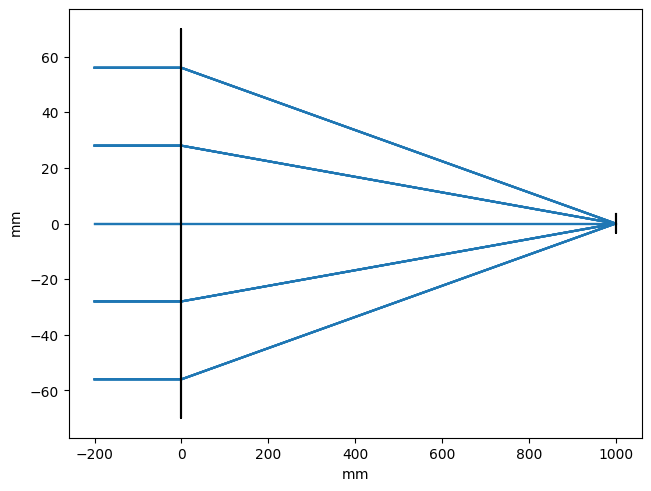

In [86]:
# Use a coarser, on-axis pupil grid for the layout diagram
pupil_layout = na.Cartesian2dVectorLinearSpace(
    start=-radius_aperture,
    stop=radius_aperture,
    axis=na.Cartesian2dVectorArray("px", "py"),
    num=5,
    centers=True,
)

raytrace_layout = system.raytrace(
    field=na.Cartesian2dVectorArray(0 * u.deg, 0 * u.deg),
    pupil=pupil_layout,
    normalized_field=False,
    normalized_pupil=False,
)

with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(constrained_layout=True)
    system.plot(
        ax=ax,
        components=("z", "y"),
        color="black",
        zorder=10,
        plot_rays=False,
    )
    na.plt.plot(
        raytrace_layout.outputs.position,
        ax=ax,
        axis=system.axis_surface,
        components=("z", "y"),
        color="tab:blue",
    )

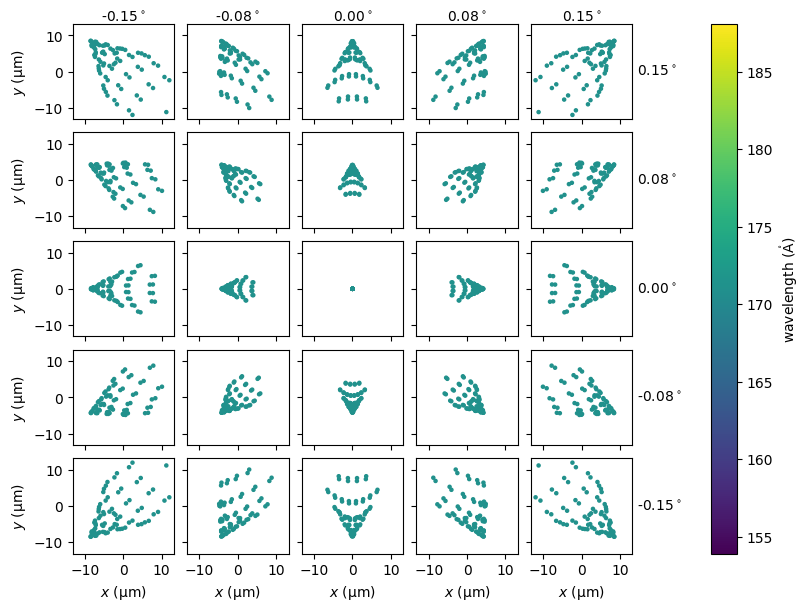

In [87]:
fig, ax = system.spot_diagram()

## Diffraction-limited performance

An ideal FZP focuses on-axis collimated light to a single geometric point — the only resolution limit is diffraction. The radius of the first dark ring of the Airy disk sets the diffraction limit:

$$r_\mathrm{Airy} = \frac{1.22\,\lambda\,f}{D}$$

We verify this by tracing a dense on-axis pupil grid and comparing the geometric RMS spot radius to $r_\mathrm{Airy}$.

In [88]:
r_airy = (1.22 * wavelength * focal_length / (2 * radius_aperture)).to(u.um)
r_airy

<Quantity 0.14901429 um>

In [89]:
# Dense on-axis pupil grid — use even num to avoid (0, 0)
pupil_dense = na.Cartesian2dVectorLinearSpace(
    start=-radius_aperture,
    stop=radius_aperture,
    axis=na.Cartesian2dVectorArray("px_dense", "py_dense"),
    num=50,
    centers=True,
)

rays_onaxis = system.rayfunction(
    field=na.Cartesian2dVectorArray(0 * u.deg, 0 * u.deg),
    pupil=pupil_dense,
    normalized_field=False,
    normalized_pupil=False,
).outputs

where = rays_onaxis.unvignetted.ndarray
pos_x = rays_onaxis.position.x.to(u.um).ndarray.value  # plain float array, in um
pos_y = rays_onaxis.position.y.to(u.um).ndarray.value

centroid_x = np.mean(pos_x[where])
centroid_y = np.mean(pos_y[where])
dx = pos_x[where] - centroid_x
dy = pos_y[where] - centroid_y

r_geometric = np.sqrt(np.mean(dx**2 + dy**2))  # um

print(f"Airy disk radius (first dark ring):  {r_airy:.4f}")
print(f"Geometric RMS spot radius (on-axis): {r_geometric:.4e} um")
print(f"Ratio (geometric / Airy):            {r_geometric / r_airy.value:.2e}")

Airy disk radius (first dark ring):  0.1490 um
Geometric RMS spot radius (on-axis): 3.3354e-07 um
Ratio (geometric / Airy):            2.24e-06


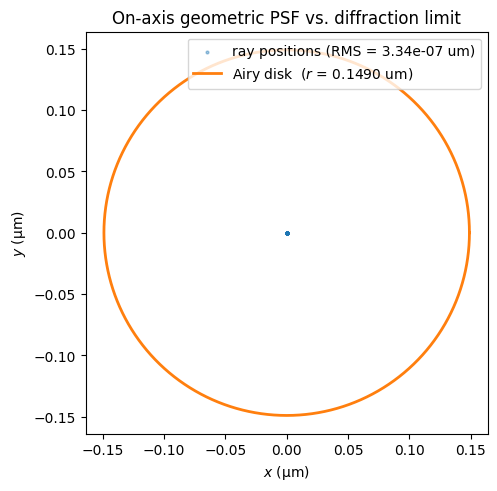

In [90]:
theta = np.linspace(0, 2 * np.pi, 361)
x_airy = r_airy.value * np.cos(theta)
y_airy = r_airy.value * np.sin(theta)

with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(constrained_layout=True)
    ax.scatter(dx, dy, s=4, alpha=0.4, color="tab:blue",
               label=f"ray positions (RMS = {r_geometric:.2e} um)")
    ax.plot(x_airy, y_airy, color="tab:orange", lw=2,
            label=f"Airy disk  ($r$ = {r_airy:.4f})")
    ax.set_aspect("equal")
    ax.set_xlabel(f"$x$ ({u.um:latex_inline})")
    ax.set_ylabel(f"$y$ ({u.um:latex_inline})")
    ax.legend()
    ax.set_title("On-axis geometric PSF vs. diffraction limit")

## Chromatic aberration

Zone plates are notorious for strong chromatic aberration: focal length scales *inversely* with wavelength,

$$f(\lambda) = f_0 \frac{\lambda_0}{\lambda}$$

where $\lambda_0 = 171$ Å and $f_0 = 1000$ mm are the design values.
A wavelength offset $\Delta\lambda$ produces a defocused disk of radius

$$r_\mathrm{blur} = R_\mathrm{pupil}\left|1 - \frac{\lambda}{\lambda_0}\right| \approx R_\mathrm{pupil} \frac{|\Delta\lambda|}{\lambda_0}$$

at the design focal plane.
We use *asymmetric* offsets (−2 Å and +3 Å from 171 Å) so the three spots
have distinct radii (0, 0.82 mm, and 1.23 mm) and are visually separable.

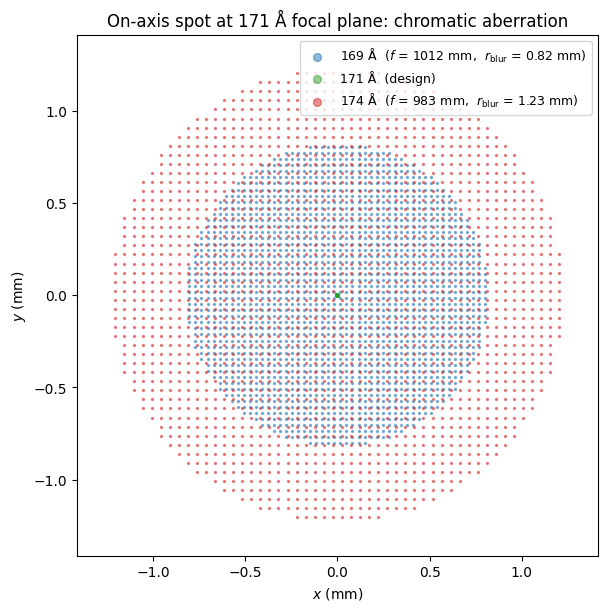

In [91]:
# Build the on-axis pupil grid from the 1-D coordinate arrays.
# Using meshgrid with indexing='ij' guarantees consistent (x, y) pairing
# and avoids axis-ordering ambiguity in the named_arrays output arrays.
px_1d = pupil_dense.x.to(u.mm).ndarray.value   # (50,)  px_dense
py_1d = pupil_dense.y.to(u.mm).ndarray.value   # (50,)  py_dense
px_2d, py_2d = np.meshgrid(px_1d, py_1d, indexing="ij")  # (50, 50)
inside = np.sqrt(px_2d**2 + py_2d**2) <= radius_aperture.to(u.mm).value

wl_design = wavelength.to(u.AA).value   # 171
f0        = focal_length.to(u.mm).value  # 1000

# Asymmetric wavelengths so each spot has a distinct radius.
# Radii: 169 Å → 0.82 mm, 171 Å → 0 (design), 174 Å → 1.23 mm
wavelengths_plot = [169, 171, 174]
colors = ["tab:blue", "tab:green", "tab:red"]
labels = [
    f"169 Å  ($f$ = {f0 * wl_design / 169:.0f} mm,  $r_\\mathrm{{blur}}$ = {70 * abs(1 - 169/wl_design):.2f} mm)",
    "171 Å  (design)",
    f"174 Å  ($f$ = {f0 * wl_design / 174:.0f} mm,  $r_\\mathrm{{blur}}$ = {70 * abs(1 - 174/wl_design):.2f} mm)",
]

# Compute max disk radius for axis limits
r_max = max(70 * abs(1 - wl / wl_design) for wl in wavelengths_plot)

with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(constrained_layout=True, figsize=(6, 6))
    for wl_val, color, label in zip(wavelengths_plot, colors, labels):
        f_wl  = f0 * wl_design / wl_val     # focal length at this wavelength, mm
        scale = 1.0 - f0 / f_wl             # defocus magnification (0 at design λ)
        x_det = px_2d[inside] * scale
        y_det = py_2d[inside] * scale
        ax.scatter(x_det, y_det, s=2, alpha=0.5, color=color,
                   label=label, rasterized=True)
    margin = 1.15
    ax.set_xlim(-r_max * margin, r_max * margin)
    ax.set_ylim(-r_max * margin, r_max * margin)
    ax.set_aspect("equal")
    ax.legend(markerscale=4, fontsize=9)
    ax.set_xlabel("$x$ (mm)")
    ax.set_ylabel("$y$ (mm)")
    ax.set_title("On-axis spot at 171 Å focal plane: chromatic aberration")